In [8]:
import numpy as np 
import pandas as pd 
import torch 
from stable_baselines3 import PPO 
import gymnasium as gym 
import matplotlib.pyplot as plt 

In [19]:
df=pd.read_csv("tesla.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,29-06-2010,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,30-06-2010,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,01-07-2010,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,02-07-2010,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,06-07-2010,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [31]:
# df.set_index('Date',inplace=True)
df.drop(columns='Adj Close',inplace=True)
df.head()

KeyError: "['Adj Close'] not found in axis"

In [14]:
df.shape

(2193, 6)

In [32]:
df.iloc[0]

Open      1.900000e+01
High      2.500000e+01
Low       1.754000e+01
Close     2.389000e+01
Volume    1.876630e+07
Name: 29-06-2010, dtype: float64

In [16]:
from gymnasium.spaces import Box,Discrete

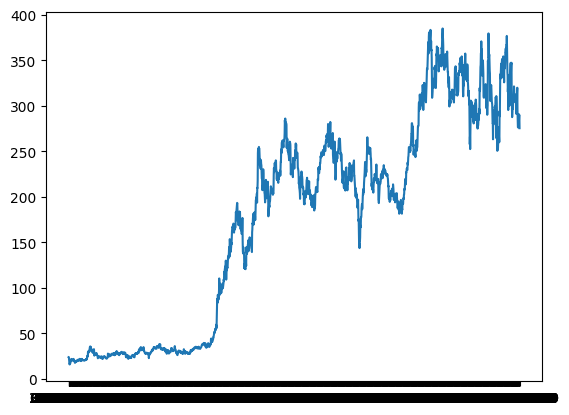

In [20]:
# feature enginneirng 

plt.plot(df['Date'],df['Close'])

<BarContainer object of 2193 artists>

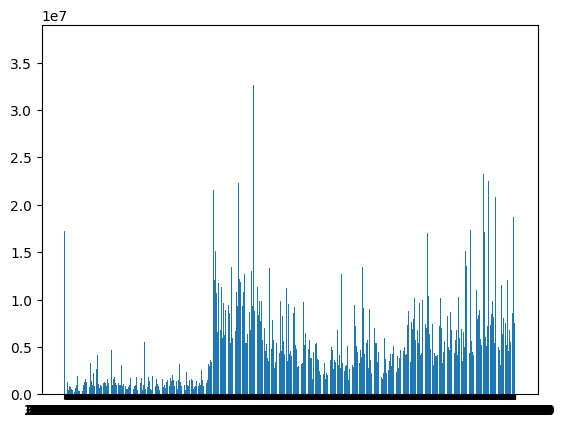

In [21]:
plt.bar(df['Date'],df['Volume'])

In [25]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [23]:
from gymnasium import Env
from enum import Enum

In [46]:
# df['High']

Date
29-06-2010     25.000000
30-06-2010     30.420000
01-07-2010     25.920000
02-07-2010     23.100000
06-07-2010     20.000000
                 ...    
11-03-2019    291.279999
12-03-2019    288.070007
13-03-2019    291.989990
14-03-2019    295.390015
15-03-2019    283.723999
Name: High, Length: 2193, dtype: float64

In [24]:
class Action(Enum): 
    BUY=0
    SELL=1
    HOLD=2

In [33]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
29-06-2010,19.000000,25.00,17.540001,23.889999,18766300
30-06-2010,25.790001,30.42,23.299999,23.830000,17187100
01-07-2010,25.000000,25.92,20.270000,21.959999,8218800
02-07-2010,23.000000,23.10,18.709999,19.200001,5139800
06-07-2010,20.000000,20.00,15.830000,16.110001,6866900


In [40]:
# for i in range(len(df)): 
#     if i==0: 
#         df.iloc[i]['gap_open_change']=0
#         df.iloc[i]['pct_change_volume']=0
#         df.iloc[i]['pct_daily_return']=0
#     df.iloc[i]['gap_open_change']=(df.iloc[i]['Open']-df.iloc[i-1]['Close'])/df.iloc[i-1]['Close']
#     df.iloc[i]['pct_change_volume']=df.iloc[i]['Volume']/df.iloc[i-1]['Volume']
#     df.iloc[i]['pct_daily_return']=(df.iloc[i]['Close']-df.iloc[i-1]['Close'])/df.iloc[i-1]['Close']

In [41]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
29-06-2010,19.000000,25.00,17.540001,23.889999,18766300
30-06-2010,25.790001,30.42,23.299999,23.830000,17187100
01-07-2010,25.000000,25.92,20.270000,21.959999,8218800
02-07-2010,23.000000,23.10,18.709999,19.200001,5139800
06-07-2010,20.000000,20.00,15.830000,16.110001,6866900


In [139]:
class TradeEnv(Env): 
    def __init__(self,target_days:int,capital:float,df,render_mode=None): 
        self.current_day=0
        self.action_space=Discrete(len(Action))
        self.observation_space=Box(low=0,high=1000,shape=(target_days,df.shape[-1]))
        self.amt=0
        self.capital=capital
        self.data=df
        self.is_holding=False
        self.render_mode=render_mode

    def reset(self,seed=None,options=None):
        self.current_day=0
        self.state=self.data.iloc[self.current_day:self.current_day+7].values
        info={}
        self.amt=0
        self.is_holding=False
        return self.state,info
    def stop_loss_hit(self):
        """ sets to 2% for the price"""
        trigger=self.amt*0.2
        if self.amt<self.amt-trigger:
            return True
        return False
    def deduce_tax(self): 
        self.amt-=self.amt*0.1
        return self.amt
    def increase(self,amt):
        self.amt=+amt
        

    def step(self,action) :
        """ performs actionsn """
        if action==0 and self.capital>0: 
            self.amt=self.capital
            self.is_holding=True
            reward=0 
            done=False
        elif action==1 and self.is_holding==True: 
            reward=np.log(self.amt/self.capital)-self.deduce_tax()
            done=True
        else:
            reward=-0.1
            done=False
        self.current_day+=1
        self.state=self.data.iloc[self.current_day:self.current_day+7].values
        info={}
        print(Action(action))
        return self.state,reward,done,False,info
    def render(self):
        super().render()
    

        
        

In [140]:
b=Box(low=0,high=1000000,shape=(7,df.shape[-1]))

In [141]:
np.log(199/23)

2.1578106087953426

In [142]:
b.sample()

array([[424003.44 , 864529.9  , 130230.93 , 179699.75 , 831622.56 ],
       [238020.73 , 403207.4  , 211517.62 , 521396.78 ,  33986.76 ],
       [843902.1  , 781696.06 , 118266.58 , 707231.5  , 502568.72 ],
       [144677.97 , 609024.94 ,  19541.156, 332725.16 , 816531.9  ],
       [905517.8  , 154209.56 , 947829.2  , 335840.34 , 427719.88 ],
       [ 53450.84 , 462760.78 , 387248.03 , 731581.56 , 475149.4  ],
       [175878.84 , 631136.   ,  90023.234, 499186.5  , 536454.1  ]],
      dtype=float32)

In [143]:
df.iloc[0:7].values

array([[1.9000000e+01, 2.5000000e+01, 1.7540001e+01, 2.3889999e+01,
        1.8766300e+07],
       [2.5790001e+01, 3.0420000e+01, 2.3299999e+01, 2.3830000e+01,
        1.7187100e+07],
       [2.5000000e+01, 2.5920000e+01, 2.0270000e+01, 2.1959999e+01,
        8.2188000e+06],
       [2.3000000e+01, 2.3100000e+01, 1.8709999e+01, 1.9200001e+01,
        5.1398000e+06],
       [2.0000000e+01, 2.0000000e+01, 1.5830000e+01, 1.6110001e+01,
        6.8669000e+06],
       [1.6400000e+01, 1.6629999e+01, 1.4980000e+01, 1.5800000e+01,
        6.9217000e+06],
       [1.6139999e+01, 1.7520000e+01, 1.5570000e+01, 1.7459999e+01,
        7.7114000e+06]])

In [144]:
env=TradeEnv(7,1000.00,df)

In [145]:
env.action_space

Discrete(3)

In [146]:
env.reset()

(array([[1.9000000e+01, 2.5000000e+01, 1.7540001e+01, 2.3889999e+01,
         1.8766300e+07],
        [2.5790001e+01, 3.0420000e+01, 2.3299999e+01, 2.3830000e+01,
         1.7187100e+07],
        [2.5000000e+01, 2.5920000e+01, 2.0270000e+01, 2.1959999e+01,
         8.2188000e+06],
        [2.3000000e+01, 2.3100000e+01, 1.8709999e+01, 1.9200001e+01,
         5.1398000e+06],
        [2.0000000e+01, 2.0000000e+01, 1.5830000e+01, 1.6110001e+01,
         6.8669000e+06],
        [1.6400000e+01, 1.6629999e+01, 1.4980000e+01, 1.5800000e+01,
         6.9217000e+06],
        [1.6139999e+01, 1.7520000e+01, 1.5570000e+01, 1.7459999e+01,
         7.7114000e+06]]),
 {})

In [147]:
env.step(1)

Action.SELL


(array([[2.5790001e+01, 3.0420000e+01, 2.3299999e+01, 2.3830000e+01,
         1.7187100e+07],
        [2.5000000e+01, 2.5920000e+01, 2.0270000e+01, 2.1959999e+01,
         8.2188000e+06],
        [2.3000000e+01, 2.3100000e+01, 1.8709999e+01, 1.9200001e+01,
         5.1398000e+06],
        [2.0000000e+01, 2.0000000e+01, 1.5830000e+01, 1.6110001e+01,
         6.8669000e+06],
        [1.6400000e+01, 1.6629999e+01, 1.4980000e+01, 1.5800000e+01,
         6.9217000e+06],
        [1.6139999e+01, 1.7520000e+01, 1.5570000e+01, 1.7459999e+01,
         7.7114000e+06],
        [1.7580000e+01, 1.7900000e+01, 1.6549999e+01, 1.7400000e+01,
         4.0506000e+06]]),
 -0.1,
 False,
 False,
 {})

In [148]:
env.render()

NotImplementedError: 

In [ ]:
class TradeEnv(Env):
    def __init__(self):
        

In [124]:
model=PPO('MlpPolicy',env,verbose=1)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [126]:
model.learn(total_timesteps=20)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5.98     |
|    ep_rew_mean     | -900     |
| time/              |          |
|    fps             | 257      |
|    iterations      | 1        |
|    time_elapsed    | 7        |
|    total_timesteps | 2048     |
---------------------------------


In [159]:
v=model.predict(df.iloc[16:23].values)
print(v)

(array(0, dtype=int64), None)


In [160]:
env.step(v[0])

Action.BUY


(array([[2.0000000e+01, 2.0000000e+01, 1.5830000e+01, 1.6110001e+01,
         6.8669000e+06],
        [1.6400000e+01, 1.6629999e+01, 1.4980000e+01, 1.5800000e+01,
         6.9217000e+06],
        [1.6139999e+01, 1.7520000e+01, 1.5570000e+01, 1.7459999e+01,
         7.7114000e+06],
        [1.7580000e+01, 1.7900000e+01, 1.6549999e+01, 1.7400000e+01,
         4.0506000e+06],
        [1.7950001e+01, 1.8070000e+01, 1.7000000e+01, 1.7049999e+01,
         2.2025000e+06],
        [1.7389999e+01, 1.8639999e+01, 1.6900000e+01, 1.8139999e+01,
         2.6801000e+06],
        [1.7940001e+01, 2.0150000e+01, 1.7760000e+01, 1.9840000e+01,
         4.1952000e+06]]),
 0,
 False,
 False,
 {})